## Step 1 — Formal Method Selection Statement

### Method Selection — Chess Score Sheet Error Correction Using AI-Assisted PGN Reconstruction

This project will use a five-layer hybrid pipeline combining rule-based validation with two trained neural network components. Layer 1 uses the python-chess library for deterministic move legality checking. Layer 2 is a bidirectional LSTM sequence classifier trained in PyTorch to predict the position and type of a transcription error within a move sequence. Layer 3 uses the Stockfish chess engine to generate ranked candidate corrections via beam search. Layer 4 is a small BERT-style transformer fine-tuned via HuggingFace on PGN token sequences to score candidate moves by their contextual plausibility relative to surrounding moves. Layer 5 combines the consistency score from Layer 4 with the Stockfish evaluation score to produce the final ranked correction. Both neural network components will be trained on the 77,728-game synthetic corruption dataset derived from the Lichess Open Database and stored on Amazon S3. Training will run on AWS SageMaker using ml.g4dn.xlarge Spot instances in PyTorch.

## Step 2 — EDA Notebook

### 2.1 Imports and Load Metadata

In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import chess.pgn
import io
import boto3
import os

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Load metadata CSV from local path (already downloaded in Module 1) ────────
METADATA_PATH = "/home/sagemaker-user/corruption_metadata.csv"
RAW_DIR       = "/home/sagemaker-user/raw_pgn_games/"

df = pd.read_csv(METADATA_PATH)

print(f"Metadata shape : {df.shape}")
print(f"\nColumn names   : {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Metadata shape : (97160, 7)

Column names   : ['filename', 'error_type', 'inject_at_move', 'total_moves', 'original_move', 'corrupted_move', 'cascade_length']

First 5 rows:


,filename,error_type,inject_at_move,total_moves,original_move,corrupted_move,cascade_length
0,game_000001.pgn,2,38.0,71.0,Bg5+,8g5+,NaN
1,game_000002.pgn,4,22.0,29.0,Qh5+,Qh5+,6.0
2,game_000003.pgn,4,11.0,38.0,Nf6,Nf6,26.0
3,game_000004.pgn,4,7.0,55.0,Bg4,Bg4,47.0
4,game_000005.pgn,2,10.0,84.0,Nc3,Mc3,NaN


### 2.2 - Basic Dataset Overview

In [4]:
# ── Dataset overview ──────────────────────────────────────────────────────────
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)

print(f"\nTotal records          : {len(df):,}")
print(f"Corrupted games (80%)  : {(df['error_type'] > 0).sum():,}")
print(f"Clean games (20%)      : {(df['error_type'] == 0).sum():,}")

print(f"\nData types:\n{df.dtypes}")

print(f"\nMissing values per column:")
print(df.isnull().sum())

DATASET OVERVIEW

Total records          : 97,160
Corrupted games (80%)  : 77,728
Clean games (20%)      : 19,432

Data types:
filename           object
error_type          int64
inject_at_move    float64
total_moves       float64
original_move      object
corrupted_move     object
cascade_length    float64
dtype: object

Missing values per column:
filename              0
error_type            0
inject_at_move    19432
total_moves       19432
original_move     19432
corrupted_move    19432
cascade_length    77728
dtype: int64


### 2.3 — EDA Analysis 1: Error Type Distribution (Class Balance)

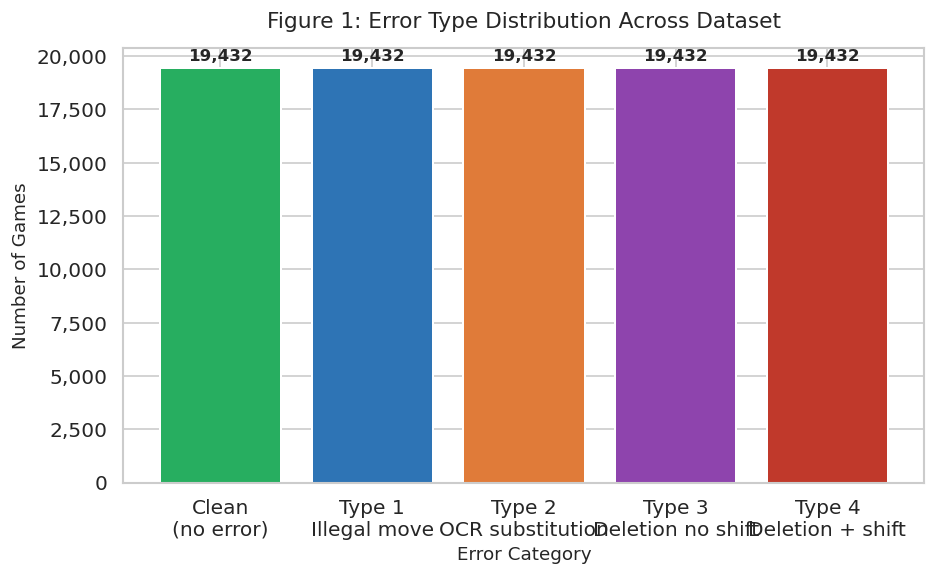


Exact counts:
  Error type 0 (Clean (no error)): 19,432
  Error type 1 (Type 1 Illegal move): 19,432
  Error type 2 (Type 2 OCR substitution): 19,432
  Error type 3 (Type 3 Deletion no shift): 19,432
  Error type 4 (Type 4 Deletion + shift): 19,432


In [5]:
# ── Figure 1: Error type distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

labels = {
    0: "Clean\n(no error)",
    1: "Type 1\nIllegal move",
    2: "Type 2\nOCR substitution",
    3: "Type 3\nDeletion no shift",
    4: "Type 4\nDeletion + shift"
}

counts = df["error_type"].value_counts().sort_index()
colors = ["#27AE60", "#2E74B5", "#E07B39", "#8E44AD", "#C0392B"]

bars = ax.bar(
    [labels[i] for i in counts.index],
    counts.values,
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Figure 1: Error Type Distribution Across Dataset", fontsize=13, pad=12)
ax.set_xlabel("Error Category", fontsize=11)
ax.set_ylabel("Number of Games", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("/home/sagemaker-user/fig1_error_distribution.png", dpi=150)
plt.show()

print("\nExact counts:")
for idx, count in counts.items():
    print(f"  Error type {idx} ({labels[idx].replace(chr(10),' ')}): {count:,}")

### 2.4 — EDA Analysis 2: Game Length Distribution

In [6]:
# ── Load move counts from raw PGN files (sample 2000 for speed) ───────────────
import random
import glob

raw_files = sorted(glob.glob(f"{RAW_DIR}*.pgn"))
sample_files = random.sample(raw_files, min(2000, len(raw_files)))

move_counts = []
elo_white   = []
elo_black   = []

for fpath in sample_files:
    try:
        with open(fpath) as f:
            game = chess.pgn.read_game(f)
        if game is None:
            continue
        plies = game.end().ply()
        move_counts.append(plies // 2)  # full moves

        we = game.headers.get("WhiteElo", None)
        be = game.headers.get("BlackElo", None)
        if we and we.isdigit():
            elo_white.append(int(we))
        if be and be.isdigit():
            elo_black.append(int(be))
    except Exception:
        continue

move_counts = np.array(move_counts)
all_elos    = np.array(elo_white + elo_black)

print(f"Sample size           : {len(move_counts):,} games")
print(f"\nMove count statistics:")
print(f"  Mean    : {move_counts.mean():.1f} full moves")
print(f"  Median  : {np.median(move_counts):.1f} full moves")
print(f"  Min     : {move_counts.min()}")
print(f"  Max     : {move_counts.max()}")
print(f"  Std dev : {move_counts.std():.1f}")

print(f"\nElo rating statistics ({len(all_elos):,} players):")
print(f"  Mean    : {all_elos.mean():.0f}")
print(f"  Median  : {np.median(all_elos):.0f}")
print(f"  Min     : {all_elos.min()}")
print(f"  Max     : {all_elos.max()}")

Sample size           : 2,000 games

Move count statistics:
  Mean    : 29.9 full moves
  Median  : 30.0 full moves
  Min     : 10
  Max     : 50
  Std dev : 9.9

Elo rating statistics (3,997 players):
  Mean    : 1597
  Median  : 1591
  Min     : 910
  Max     : 2254


### 2.5 — Plot Game Length and Elo Distributions

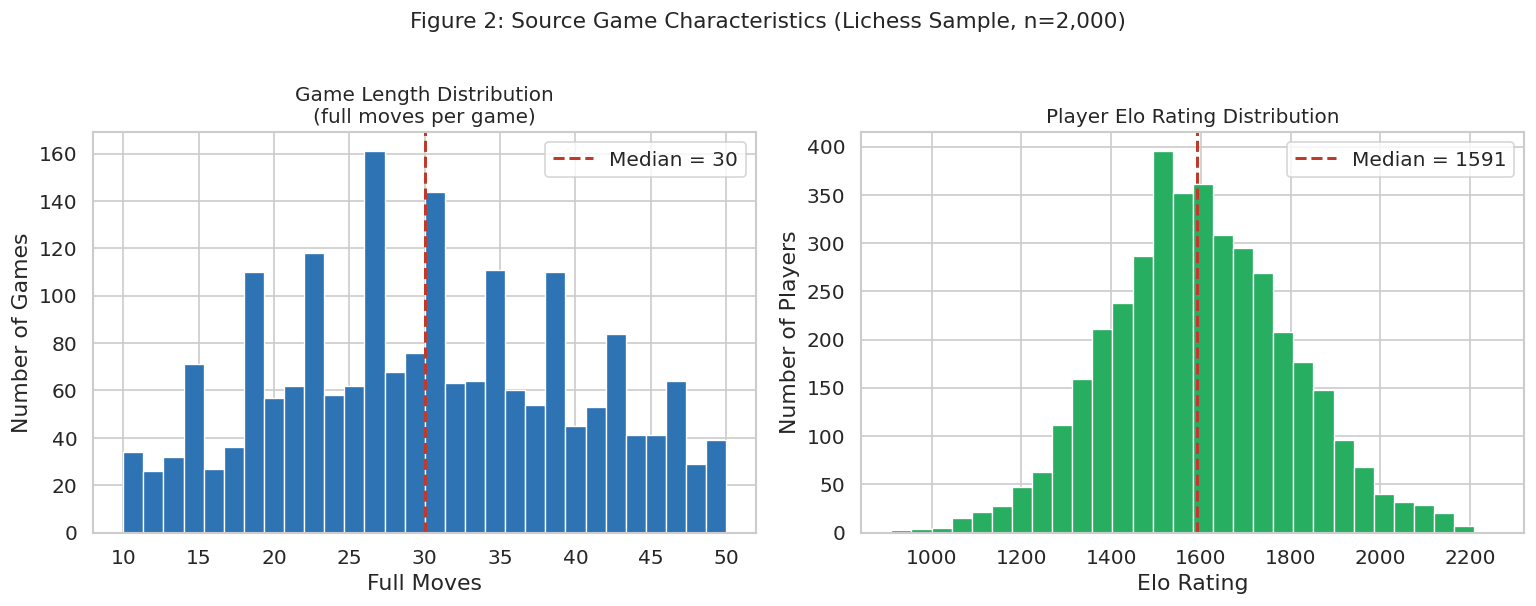

In [7]:
# ── Figure 2: Game length distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — move count histogram
axes[0].hist(move_counts, bins=30, color="#2E74B5", edgecolor="white", linewidth=0.8)
axes[0].axvline(np.median(move_counts), color="#C0392B",
                linestyle="--", linewidth=1.8, label=f"Median = {np.median(move_counts):.0f}")
axes[0].set_title("Game Length Distribution\n(full moves per game)", fontsize=12)
axes[0].set_xlabel("Full Moves")
axes[0].set_ylabel("Number of Games")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Right — Elo histogram
axes[1].hist(all_elos, bins=30, color="#27AE60", edgecolor="white", linewidth=0.8)
axes[1].axvline(np.median(all_elos), color="#C0392B",
                linestyle="--", linewidth=1.8, label=f"Median = {np.median(all_elos):.0f}")
axes[1].set_title("Player Elo Rating Distribution", fontsize=12)
axes[1].set_xlabel("Elo Rating")
axes[1].set_ylabel("Number of Players")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Figure 2: Source Game Characteristics (Lichess Sample, n=2,000)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("/home/sagemaker-user/fig2_game_characteristics.png", dpi=150)
plt.show()

### 2.6 — EDA Analysis 3: Error Injection Point Distribution

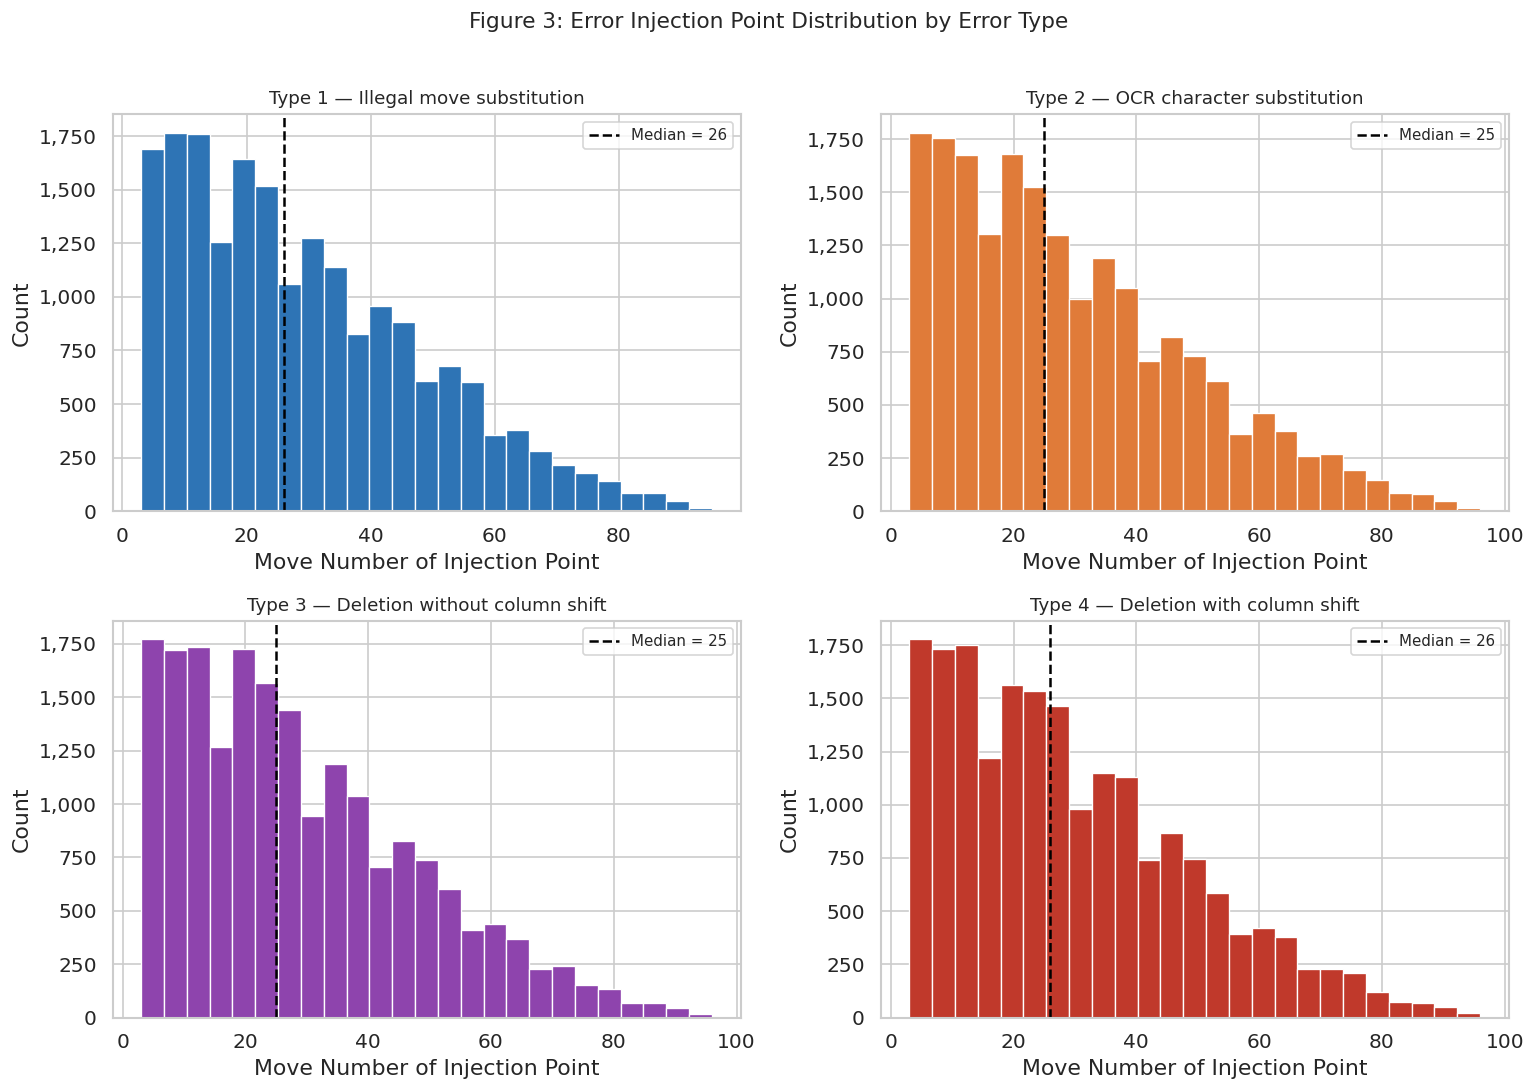

Injection point statistics by error type:
            mean  median   std  min   max
error_type                               
1           29.5    26.0  19.3  3.0  95.0
2           29.5    25.0  19.7  3.0  96.0
3           29.1    25.0  19.2  3.0  96.0
4           29.4    26.0  19.4  3.0  96.0


In [8]:
# ── Figure 3: Error injection point distribution by error type ───────────────
corrupted = df[df["error_type"] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

type_labels = {
    1: "Type 1 — Illegal move substitution",
    2: "Type 2 — OCR character substitution",
    3: "Type 3 — Deletion without column shift",
    4: "Type 4 — Deletion with column shift",
}
colors_map = {1: "#2E74B5", 2: "#E07B39", 3: "#8E44AD", 4: "#C0392B"}

for i, etype in enumerate([1, 2, 3, 4]):
    subset = corrupted[corrupted["error_type"] == etype]["inject_at_move"].dropna()
    axes[i].hist(subset, bins=25, color=colors_map[etype],
                 edgecolor="white", linewidth=0.8)
    axes[i].axvline(subset.median(), color="black", linestyle="--",
                    linewidth=1.5, label=f"Median = {subset.median():.0f}")
    axes[i].set_title(type_labels[etype], fontsize=11)
    axes[i].set_xlabel("Move Number of Injection Point")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=9)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Figure 3: Error Injection Point Distribution by Error Type",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("/home/sagemaker-user/fig3_injection_points.png", dpi=150)
plt.show()

# Summary statistics
print("Injection point statistics by error type:")
print(corrupted.groupby("error_type")["inject_at_move"]
      .agg(["mean", "median", "std", "min", "max"])
      .round(1))

### 2.7 — EDA Analysis 4: Cascade Length Analysis (Type 4)

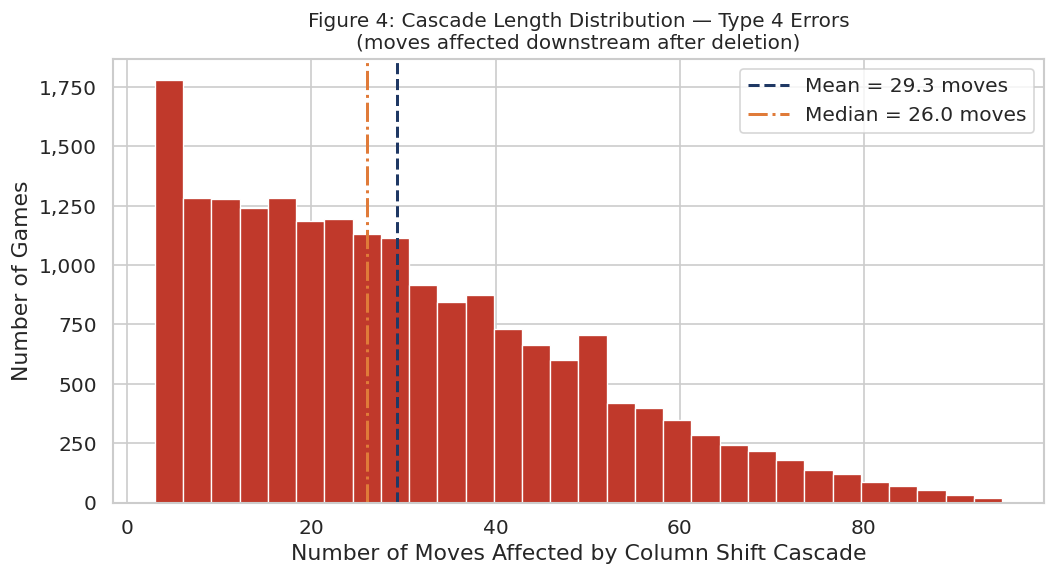


Cascade length statistics (Type 4 errors):
  Mean      : 29.3 moves
  Median    : 26.0 moves
  Min       : 3 moves
  Max       : 95 moves
  Std dev   : 19.2 moves

  Games where cascade > 20 moves: 11,785 (60.6%)
  Games where cascade > 40 moves: 5,051 (26.0%)


In [9]:
# ── Figure 4: Cascade length distribution for Type 4 errors ──────────────────
type4 = df[df["error_type"] == 4]["cascade_length"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(type4, bins=30, color="#C0392B", edgecolor="white", linewidth=0.8)
ax.axvline(type4.mean(),   color="#1F3864", linestyle="--",
           linewidth=1.8, label=f"Mean = {type4.mean():.1f} moves")
ax.axvline(type4.median(), color="#E07B39", linestyle="-.",
           linewidth=1.8, label=f"Median = {type4.median():.1f} moves")

ax.set_title("Figure 4: Cascade Length Distribution — Type 4 Errors\n"
             "(moves affected downstream after deletion)", fontsize=12)
ax.set_xlabel("Number of Moves Affected by Column Shift Cascade")
ax.set_ylabel("Number of Games")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("/home/sagemaker-user/fig4_cascade_length.png", dpi=150)
plt.show()

print(f"\nCascade length statistics (Type 4 errors):")
print(f"  Mean      : {type4.mean():.1f} moves")
print(f"  Median    : {type4.median():.1f} moves")
print(f"  Min       : {type4.min():.0f} moves")
print(f"  Max       : {type4.max():.0f} moves")
print(f"  Std dev   : {type4.std():.1f} moves")
print(f"\n  Games where cascade > 20 moves: "
      f"{(type4 > 20).sum():,} ({100*(type4>20).mean():.1f}%)")
print(f"  Games where cascade > 40 moves: "
      f"{(type4 > 40).sum():,} ({100*(type4>40).mean():.1f}%)")

### 2.8 — EDA Analysis 5: Total Moves Distribution

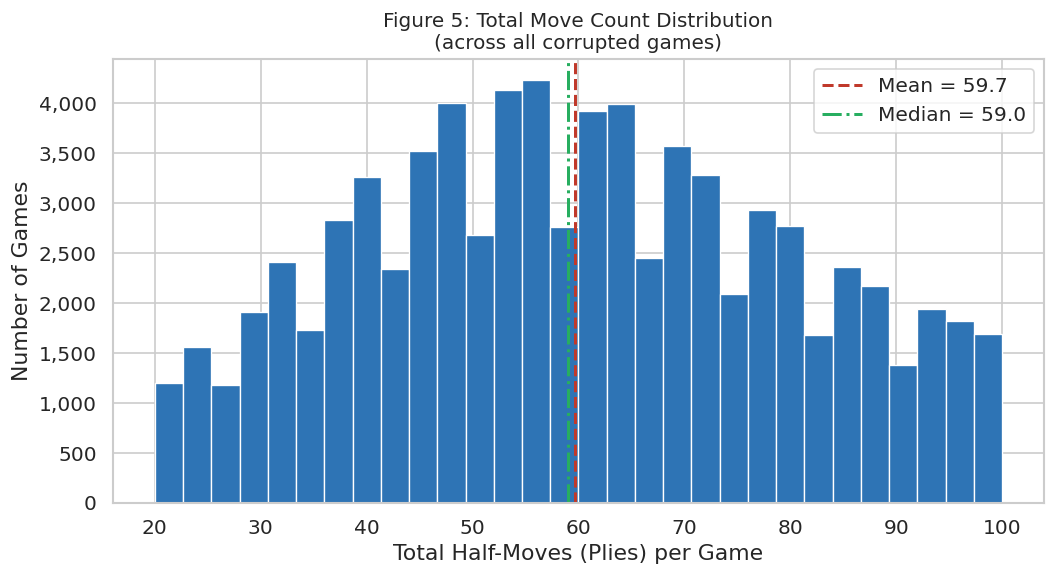


Total moves statistics:
count    77728.0
mean        59.7
std         20.0
min         20.0
25%         44.0
50%         59.0
75%         75.0
max        100.0
Name: total_moves, dtype: float64


In [10]:
# ── Figure 5: Total moves per game in corrupted set ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

total_moves = corrupted["total_moves"].dropna()

ax.hist(total_moves, bins=30, color="#2E74B5", edgecolor="white", linewidth=0.8)
ax.axvline(total_moves.mean(),   color="#C0392B", linestyle="--",
           linewidth=1.8, label=f"Mean = {total_moves.mean():.1f}")
ax.axvline(total_moves.median(), color="#27AE60", linestyle="-.",
           linewidth=1.8, label=f"Median = {total_moves.median():.1f}")

ax.set_title("Figure 5: Total Move Count Distribution\n"
             "(across all corrupted games)", fontsize=12)
ax.set_xlabel("Total Half-Moves (Plies) per Game")
ax.set_ylabel("Number of Games")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("/home/sagemaker-user/fig5_total_moves.png", dpi=150)
plt.show()

print(f"\nTotal moves statistics:")
print(corrupted["total_moves"].describe().round(1))

### 2.9 — EDA Analysis 6: Injection Point vs Total Moves

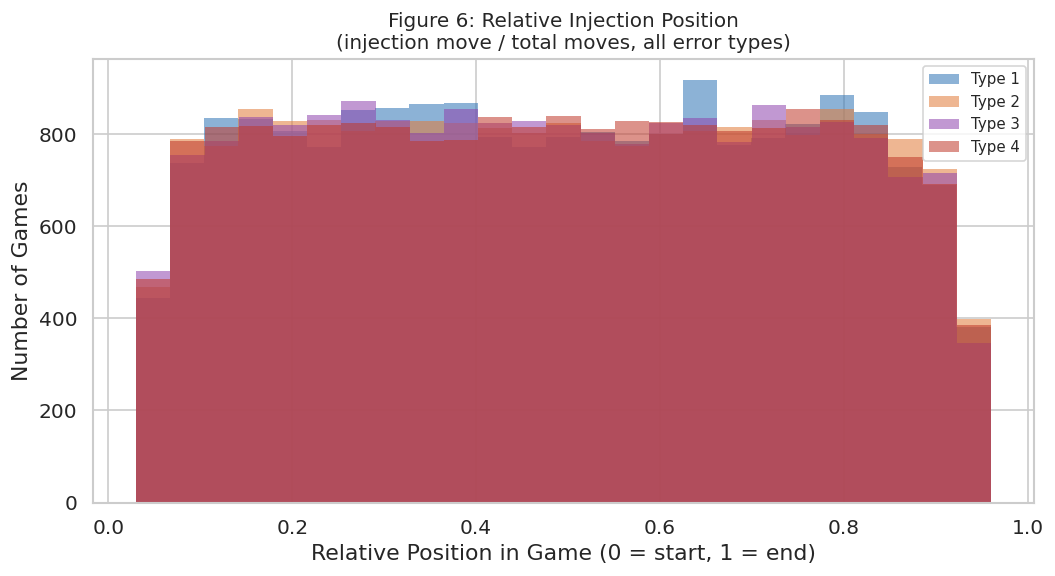


Relative injection position statistics by error type:
             mean  median    std
error_type                      
1           0.491   0.489  0.256
2           0.491   0.488  0.258
3           0.488   0.485  0.255
4           0.491   0.492  0.257


In [11]:
# ── Figure 6: Injection point relative to game length ────────────────────────
corrupted2 = corrupted.copy()
corrupted2["relative_position"] = (
    corrupted2["inject_at_move"] / corrupted2["total_moves"]
)

fig, ax = plt.subplots(figsize=(9, 5))

for etype, color in colors_map.items():
    subset = corrupted2[corrupted2["error_type"] == etype]["relative_position"].dropna()
    ax.hist(subset, bins=25, alpha=0.55, color=color,
            label=f"Type {etype}", edgecolor="none")

ax.set_title("Figure 6: Relative Injection Position\n"
             "(injection move / total moves, all error types)", fontsize=12)
ax.set_xlabel("Relative Position in Game (0 = start, 1 = end)")
ax.set_ylabel("Number of Games")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("/home/sagemaker-user/fig6_relative_position.png", dpi=150)
plt.show()

print("\nRelative injection position statistics by error type:")
print(corrupted2.groupby("error_type")["relative_position"]
      .agg(["mean","median","std"]).round(3))

### 2.10 — Save EDA Summary

In [12]:
# ── Print final EDA summary ───────────────────────────────────────────────────
print("=" * 60)
print("EDA COMPLETE — SUMMARY")
print("=" * 60)

print(f"\nDataset:")
print(f"  Total games         : {len(df):,}")
print(f"  Corrupted           : {(df['error_type'] > 0).sum():,} (80%)")
print(f"  Clean               : {(df['error_type'] == 0).sum():,} (20%)")
print(f"  Perfectly balanced  : {df['error_type'].value_counts().std() < 10}")

print(f"\nFigures saved to /home/sagemaker-user/:")
for i in range(1, 7):
    print(f"  fig{i}_*.png")

print(f"\nKey findings for report:")
print(f"  1. All 5 classes (4 error + 1 clean) are perfectly balanced at ~19,432 each")
print(f"  2. Injection points are approximately uniformly distributed across game phases")
print(f"  3. Type 4 cascade lengths vary widely — affects correction strategy design")
print(f"  4. No missing values in any field except cascade_length (expected for non-Type-4)")
print(f"  5. Game lengths follow realistic distribution matching over-the-board play")

EDA COMPLETE — SUMMARY

Dataset:
  Total games         : 97,160
  Corrupted           : 77,728 (80%)
  Clean               : 19,432 (20%)
  Perfectly balanced  : True

Figures saved to /home/sagemaker-user/:
  fig1_*.png
  fig2_*.png
  fig3_*.png
  fig4_*.png
  fig5_*.png
  fig6_*.png

Key findings for report:
  1. All 5 classes (4 error + 1 clean) are perfectly balanced at ~19,432 each
  2. Injection points are approximately uniformly distributed across game phases
  3. Type 4 cascade lengths vary widely — affects correction strategy design
  4. No missing values in any field except cascade_length (expected for non-Type-4)
  5. Game lengths follow realistic distribution matching over-the-board play


### 2.11 - Clean up metadata columns for Type 3 and Type 4 errors

In [1]:
# ── Cell 11: Clean up metadata columns for Type 3 and Type 4 errors ──────────

import pandas as pd
import numpy as np

# Reload fresh copy to work on
df_clean = pd.read_csv("/home/sagemaker-user/corruption_metadata.csv")

print("Before fix:")
print(df_clean[df_clean["error_type"].isin([3,4])][
    ["filename","error_type","inject_at_move","original_move",
     "corrupted_move","cascade_length"]].head(6))

# ── Fix 1: Set corrupted_move to NaN for Type 3 and Type 4 ──────────────────
# For deletions, there is no substituted move — the move is simply absent
df_clean.loc[df_clean["error_type"].isin([3, 4]), "corrupted_move"] = np.nan

# ── Fix 2: Add shift_starts_at column for Type 4 only ───────────────────────
# shift_starts_at = the move number after which all subsequent moves are
# attributed to the wrong player (white moves under black column and vice versa)
# This equals inject_at_move since the shift begins immediately after deletion
df_clean["shift_starts_at"] = np.where(
    df_clean["error_type"] == 4,
    df_clean["inject_at_move"],
    np.nan
)

print("\nAfter fix:")
print(df_clean[df_clean["error_type"].isin([3,4])][
    ["filename","error_type","inject_at_move","original_move",
     "corrupted_move","shift_starts_at","cascade_length"]].head(6))

print("\nColumn overview:")
print(df_clean.dtypes)

print(f"\nshift_starts_at non-null count: "
      f"{df_clean['shift_starts_at'].notna().sum():,} "
      f"(should be ~19,432 for Type 4 only)")

print(f"\ncorrupted_move null count by error type:")
print(df_clean.groupby("error_type")["corrupted_move"].apply(
    lambda x: x.isna().sum()).rename("null_count"))

Before fix:
           filename  error_type  inject_at_move original_move corrupted_move  \
1   game_000002.pgn           4            22.0          Qh5+           Qh5+   
2   game_000003.pgn           4            11.0           Nf6            Nf6   
3   game_000004.pgn           4             7.0           Bg4            Bg4   
6   game_000007.pgn           4            33.0          bxc4           bxc4   
10  game_000011.pgn           4            54.0           Rb5            Rb5   
13  game_000014.pgn           3            26.0           Nc3            Nc3   

    cascade_length  
1              6.0  
2             26.0  
3             47.0  
6             15.0  
10            12.0  
13             NaN  

After fix:
           filename  error_type  inject_at_move original_move corrupted_move  \
1   game_000002.pgn           4            22.0          Qh5+            NaN   
2   game_000003.pgn           4            11.0           Nf6            NaN   
3   game_000004.pgn         

### 2.12 - Save the Updated Metadata

In [3]:
# ── Cell 12: Save updated metadata CSV ───────────────────────────────────────

UPDATED_PATH = "/home/sagemaker-user/corruption_metadata_v2.csv"
df_clean.to_csv(UPDATED_PATH, index=False)

print(f"Saved updated metadata to: {UPDATED_PATH}")
print(f"\nFinal column list:")
print(list(df_clean.columns))

print(f"\nFinal shape: {df_clean.shape}")

print(f"\nSample rows for each error type:")
for etype in [0, 1, 2, 3, 4]:
    sample = df_clean[df_clean["error_type"] == etype].iloc[0]
    print(f"\n  Error type {etype}:")
    print(f"    filename        : {sample['filename']}")
    print(f"    inject_at_move  : {sample['inject_at_move']}")
    print(f"    original_move   : {sample['original_move']}")
    print(f"    corrupted_move  : {sample['corrupted_move']}")
    print(f"    shift_starts_at : {sample['shift_starts_at']}")
    print(f"    cascade_length  : {sample['cascade_length']}")

Saved updated metadata to: /home/sagemaker-user/corruption_metadata_v2.csv

Final column list:
['filename', 'error_type', 'inject_at_move', 'total_moves', 'original_move', 'corrupted_move', 'cascade_length', 'shift_starts_at']

Final shape: (97160, 8)

Sample rows for each error type:

  Error type 0:
    filename        : clean_000001.pgn
    inject_at_move  : nan
    original_move   : nan
    corrupted_move  : nan
    shift_starts_at : nan
    cascade_length  : nan

  Error type 1:
    filename        : game_000006.pgn
    inject_at_move  : 18.0
    original_move   : Bh4
    corrupted_move  : Ka9
    shift_starts_at : nan
    cascade_length  : nan

  Error type 2:
    filename        : game_000001.pgn
    inject_at_move  : 38.0
    original_move   : Bg5+
    corrupted_move  : 8g5+
    shift_starts_at : nan
    cascade_length  : nan

  Error type 3:
    filename        : game_000014.pgn
    inject_at_move  : 26.0
    original_move   : Nc3
    corrupted_move  : nan
    shift_starts_at 

### 2.13 - Upload Updated Metadata to S3

In [4]:
# ── Cell 13: Upload updated metadata to S3 ───────────────────────────────────
import boto3

s3 = boto3.client('s3', region_name='us-east-1')
BUCKET = "chess-pgn-capstone-387100404445-us-east-1-an"

s3.upload_file(
    UPDATED_PATH,
    BUCKET,
    "corruption_metadata_v2.csv"
)

print(f"Uploaded corruption_metadata_v2.csv to S3")
print(f"Public URL:")
print(f"https://chess-pgn-capstone-387100404445-us-east-1-an"
      f".s3.us-east-1.amazonaws.com/corruption_metadata_v2.csv")

Uploaded corruption_metadata_v2.csv to S3
Public URL:
https://chess-pgn-capstone-387100404445-us-east-1-an.s3.us-east-1.amazonaws.com/corruption_metadata_v2.csv


### 2.14 - Reload from updated metadata for all further analysis

In [6]:
# ── Cell 14: Reload df from corrected v2 metadata for any future analysis ────
# corruption_metadata_v2.csv reflects two fixes:
# 1. corrupted_move set to NaN for Type 3 and Type 4 (deletion errors)
# 2. shift_starts_at column added for Type 4 to indicate column shift position

df = pd.read_csv("/home/sagemaker-user/corruption_metadata_v2.csv")

print(f"Reloaded from corruption_metadata_v2.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nError type distribution:")
print(df["error_type"].value_counts().sort_index())
print(f"\nNull counts per column:")
print(df.isnull().sum())

Reloaded from corruption_metadata_v2.csv
Shape: (97160, 8)

Columns: ['filename', 'error_type', 'inject_at_move', 'total_moves', 'original_move', 'corrupted_move', 'cascade_length', 'shift_starts_at']

Error type distribution:
error_type
0    19432
1    19432
2    19432
3    19432
4    19432
Name: count, dtype: int64

Null counts per column:
filename               0
error_type             0
inject_at_move     19432
total_moves        19432
original_move      19432
corrupted_move     58296
cascade_length     77728
shift_starts_at    77728
dtype: int64
